<a href="https://colab.research.google.com/github/harmanbajwa2954/Python_Projects/blob/main/EDA_Rainfall_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

---


Libraries that will be used throughout the project are imported.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  classification_report,confusion_matrix, accuracy_score
import pickle

# **Data collection and Data Pre-processing**

---

now the data will be loaded into a dataframe and pre-processing will be done to get the data ready for model training.


In [ ]:
#loading the dataset to a dataframe
data = pd.read_csv('/content/Rainfall.csv')

In [ ]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
data.shape

(366, 12)

In [ ]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
data.tail()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [ ]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [ ]:
#removing extra spaces in all columns
data.columns = data.columns.str.strip()

In [ ]:
data.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [ ]:
data = data.drop(columns=["day"])

In [ ]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
#checking for missing values
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [ ]:
data["winddirection"].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [ ]:
#handling missing values
data["winddirection"] = data["winddirection"].fillna(data["winddirection"].mode()[0])
data["windspeed"] = data["windspeed"].fillna(data["windspeed"].mean())

In [ ]:
print(data.isnull().sum())

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64


Data Encoding

In [ ]:
#converting categorical values to integer values using binary encoding
data["rainfall"] = data["rainfall"].map({"yes":1, "no":0})

In [ ]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


# **Exploratory Data Analysis**(EDA)

In [ ]:
data.shape

(366, 11)

In [ ]:
#setting plot style for all the plots
sns.set(style="whitegrid")

In [ ]:
data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.536986
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.055908
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


from matplotlib import pyplot as plt
_df_0['pressure'].plot(kind='hist', bins=20, title='pressure')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['maxtemp'].plot(kind='hist', bins=20, title='maxtemp')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['temparature'].plot(kind='hist', bins=20, title='temparature')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['mintemp'].plot(kind='hist', bins=20, title='mintemp')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='mintemp', y='dewpoint', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['pressure'].plot(kind='line', figsize=(8, 4), title='pressure')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['maxtemp'].plot(kind='line', figsize=(8, 4), title='maxtemp')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['temparature'].plot(kind='line', figsize=(8, 4), title='temparature')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['mintemp'].plot(kind='line', figsize=(8, 4), title='mintemp')
plt.gca().spines[['top', 'right']].set_visible(False)

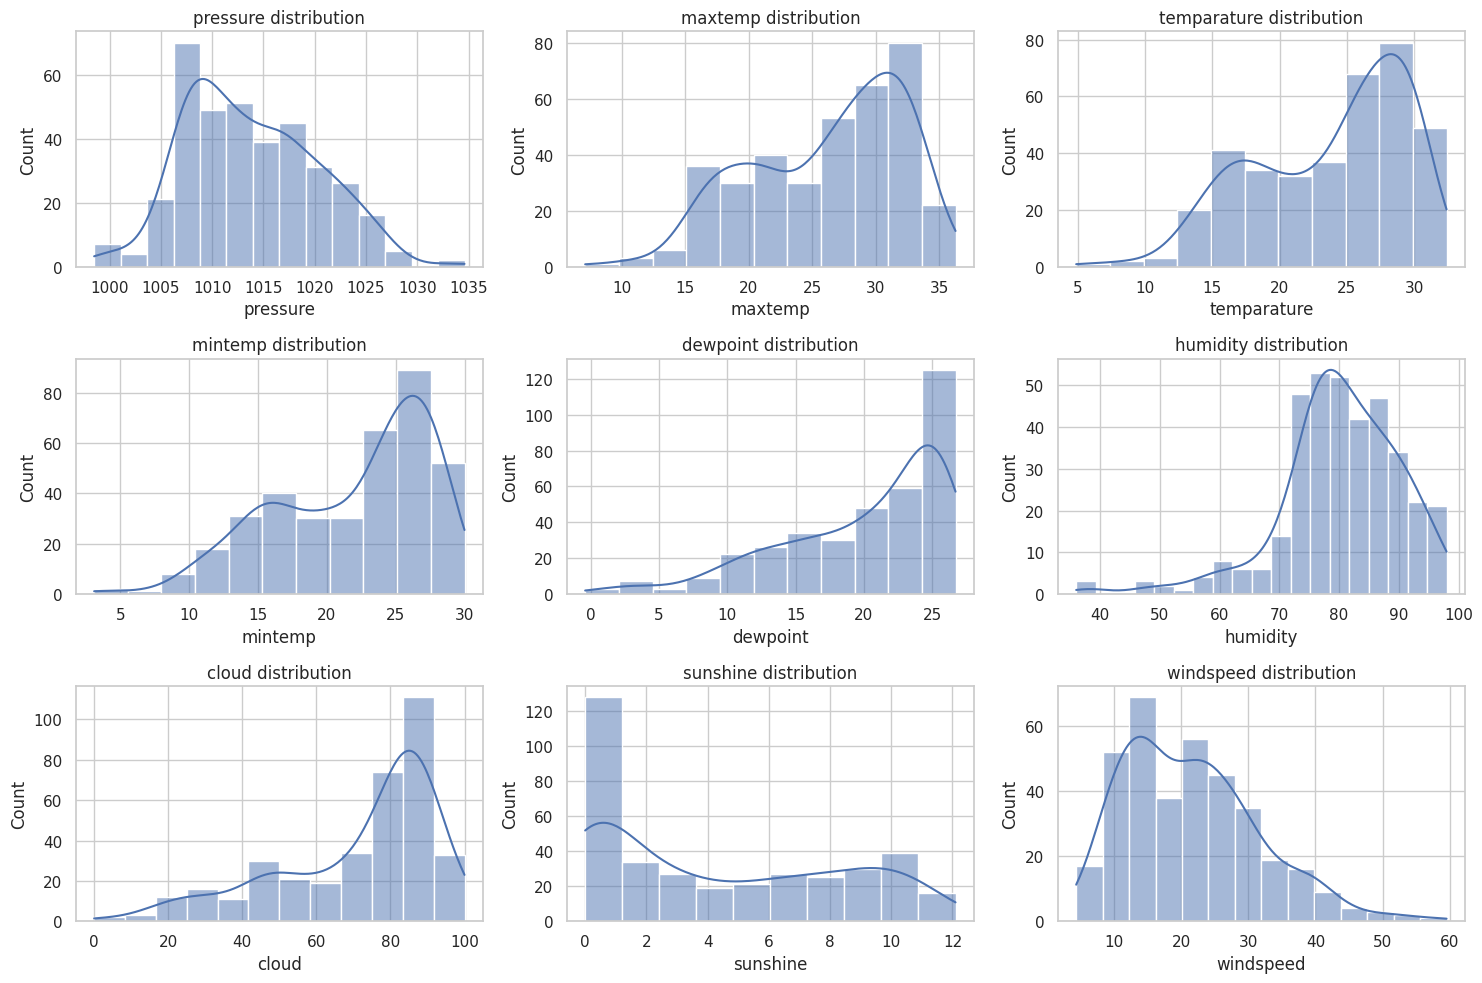

In [ ]:
plt.figure(figsize=(15,10))
for i,column in enumerate(['pressure','maxtemp','temparature','mintemp','dewpoint','humidity','cloud','sunshine','windspeed'],1):
  plt.subplot(3,3,i)
  sns.histplot(data[column],kde=True)
  plt.title(f'{column} distribution')
plt.tight_layout()
plt.show()

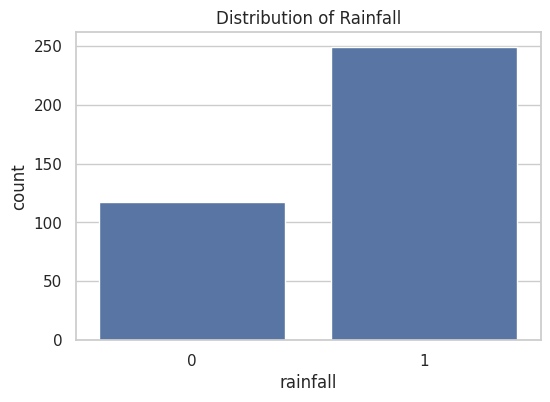

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall",data=data)
plt.title("Distribution of Rainfall")
plt.show()

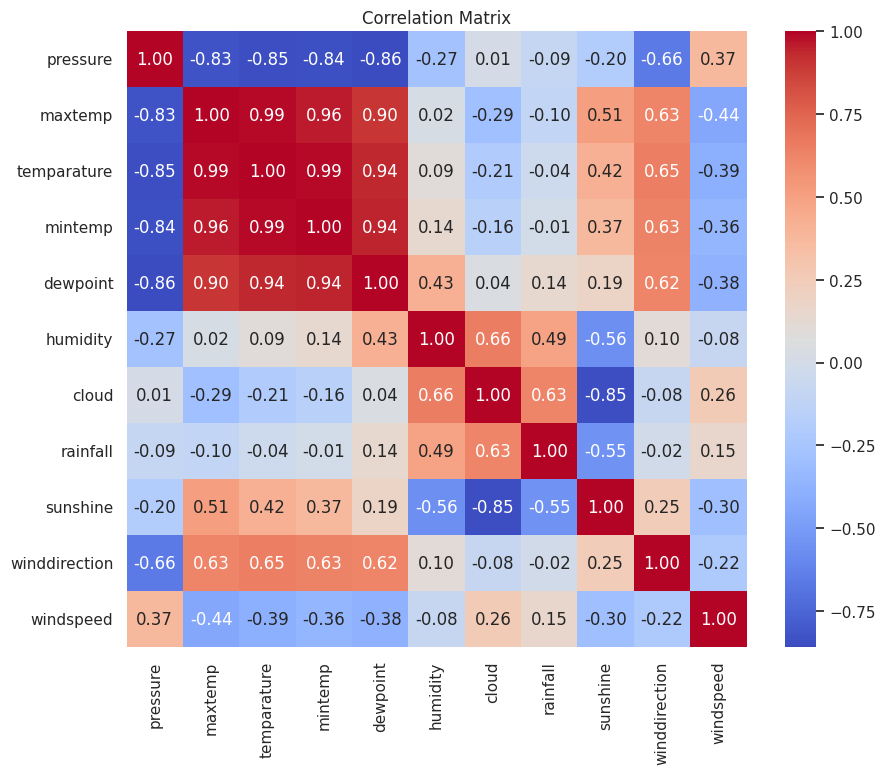

In [ ]:
#corelation matrix
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

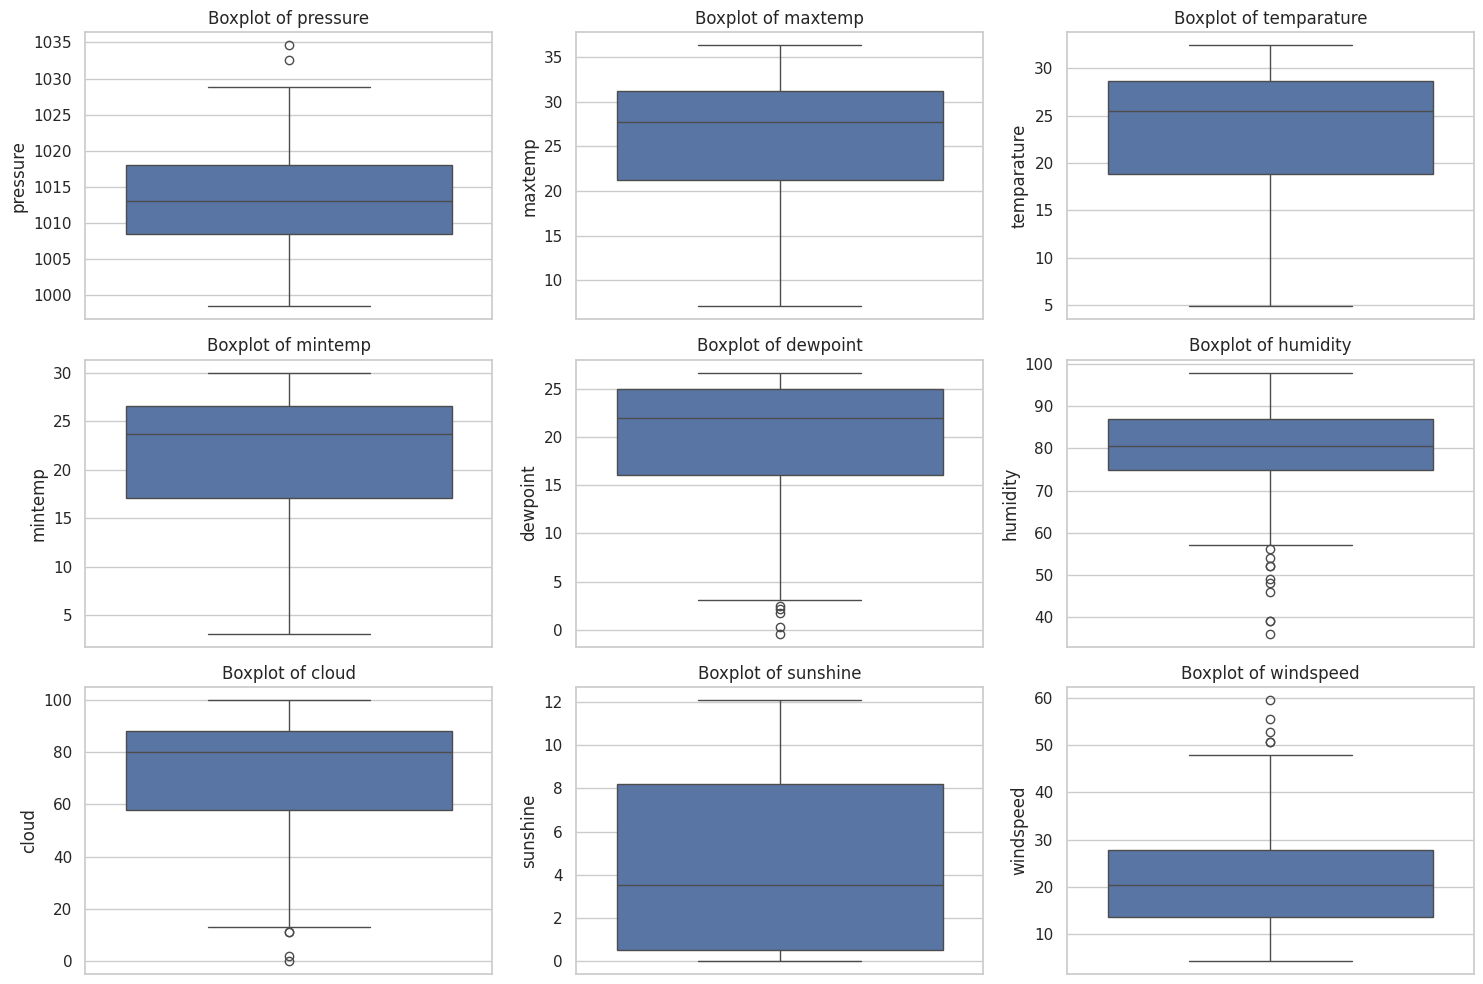

In [ ]:
#boxplot to check the presence of outliers in the data
plt.figure(figsize=(15,10))
for i,column in enumerate(['pressure','maxtemp','temparature','mintemp','dewpoint','humidity','cloud','sunshine','windspeed'],1):
  plt.subplot(3,3,i)
  sns.boxplot(data[column])
  plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

# **Data Pre-Processing**

In [ ]:
#droping highly corelated columns
data = data.drop(columns=["dewpoint","maxtemp","mintemp"])

In [ ]:
data.head()

,pressure,temparature,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,18.3,72,49,1,9.3,80.0,26.3
1,1022.0,18.9,81,83,1,0.6,50.0,15.3
2,1019.7,19.3,95,91,1,0.0,40.0,14.2
3,1018.9,20.6,90,88,1,1.0,50.0,16.9
4,1015.9,20.7,95,81,1,0.0,40.0,13.7


In [ ]:
data["rainfall"].value_counts()

,count
rainfall,
1,249
0,117


In [ ]:
#seprating majority(1) and minority(0) classes in railfall attribute
df_majority = data[data["rainfall"]==1]
df_minority = data[data["rainfall"]==0]

In [ ]:
#downsampling majority class to match minority class
df_majority_downsampled = resample(df_majority,replace=False,n_samples=len(df_minority),random_state=42)

In [ ]:
df_majority_downsampled.shape

(117, 8)

In [ ]:
#combining both majority_downsampled and minority
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [ ]:
#shuffling the final dataframe
df_downsampled = df_downsampled.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
df_downsampled.head()

,pressure,temparature,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,18.0,78,90,1,0.0,30.0,28.5
1,1013.4,26.2,69,17,0,10.5,70.0,12.4
2,1006.1,29.6,74,27,0,10.8,220.0,8.7
3,1007.6,27.6,85,84,1,1.8,70.0,34.8
4,1021.2,14.8,66,18,0,10.1,20.0,24.4


In [ ]:
df_downsampled["rainfall"].value_counts()

,count
rainfall,
1,117
0,117


# Splitting data into Training set and testing set

In [ ]:
#splitting features and targets as X and y
X = df_downsampled.drop(columns=["rainfall"])
y = df_downsampled["rainfall"]
print(X)

     pressure  temparature  humidity  cloud  sunshine  winddirection  \
0      1022.2         18.0        78     90       0.0           30.0   
1      1013.4         26.2        69     17      10.5           70.0   
2      1006.1         29.6        74     27      10.8          220.0   
3      1007.6         27.6        85     84       1.8           70.0   
4      1021.2         14.8        66     18      10.1           20.0   
..        ...          ...       ...    ...       ...            ...   
229    1008.1         28.1        86     75       5.7           20.0   
230    1010.1         21.5        91     89       0.0           70.0   
231    1020.6         16.1        91     88       0.3           50.0   
232    1008.3         29.4        74     29       5.7           10.0   
233    1005.0         28.6        87     82       2.2          160.0   

     windspeed  
0         28.5  
1         12.4  
2          8.7  
3         34.8  
4         24.4  
..         ...  
229        9.5  

In [ ]:
print(y)

0      1
1      0
2      0
3      1
4      0
      ..
229    1
230    1
231    1
232    0
233    1
Name: rainfall, Length: 234, dtype: int64


In [ ]:
#splitting the data into training set and testing set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# **Model Training**

---


The model used for this project is Random Forest Classifier ,
it is a machine learning algorithm that combines multiple decision trees to make predictions.

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [ ]:
#hypertuning using GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5,n_jobs=-1,verbose=2)
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

In [ ]:
best_rf_model = grid_search_rf.best_estimator_
print("best parameters for Random Forest", grid_search_rf.best_params_)

best parameters for Random Forest {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


# Model Evaluation

In [ ]:
cv_score = cross_val_score(best_rf_model,X_train,y_train,cv=5)
print("Cross Validation Score:",cv_score)
print("Mean Cross Validation Score:",np.mean(cv_score))

Cross Validation Score: [0.68421053 0.84210526 0.83783784 0.78378378 0.91891892]
Mean Cross Validation Score: 0.8133712660028449


In [ ]:
#test set prerformance
y_pred = best_rf_model.predict(X_test)

print("Test set Accuracy Score:",accuracy_score(y_test,y_pred))
print("Test set Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Test set Accuracy Score: 0.7446808510638298
Test set Confusion Matrix:
 [[17  7]
 [ 5 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47



# Prediction on unknown data

In [ ]:
X_train.columns

Index(['pressure', 'temparature', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [ ]:
input_data = (1013.4,19.8,95,81,0.0,40.0,13.7)
input_df = pd.DataFrame([input_data],columns=['pressure', 'temparature', 'humidity', 'cloud', 'sunshine','winddirection', 'windspeed'])
prediction = best_rf_model.predict(input_df)
print("Prediction result :",prediction)

Prediction result : [1]


# Saving the model as a Pickel file

In [ ]:
#save model and feature names to a pickle file
model_data = {"model":best_rf_model,"features":X.columns.tolist()}
with open("rainfallmodel.pkl","wb") as file:
  pickle.dump(model_data,file)

In [ ]:
import pickle
import pandas as pd


In [ ]:
with open("rainfallmodel.pkl","rb") as file:
  model_data = pickle.load(file)

In [ ]:
input_data = (900.4,19.8,75,61,0.0,20.0,3.7)
input_df = pd.DataFrame([input_data],columns=['pressure', 'temparature', 'humidity', 'cloud', 'sunshine','winddirection', 'windspeed'])
prediction  = model_data["model"].predict(input_df)
print("Prediction result :",prediction)

Prediction result : [0]
